In [ ]:
# CELL: Add taming-transformers to path (run once)
import sys
sys.path.append("src/externals/taming-transformers")  # ← adjust if your path is different
print("taming-transformers added to Python path")

## DATALOADER 

In [ ]:
# !pip install opencv-python 

In [ ]:
# !pip install albumentations 

In [1]:
import sys

sys.path.insert(0, "src")        
sys.path.append("src/datasets") 
sys.path.insert(0, "src/datasets")   #

from bcss_wsss import BCSSTrainingDataset, BCSSValidationDataset 

In [17]:
train_dataset = BCSSTrainingDataset(
    img_root="/project/hnguyen2/mvu9/datasets/weakly_sup_segmentation_datasets/BCSS-WSSS/training",
    size=224,
    transform=None
)

print(f"SUCCESS: {len(train_dataset)} images loaded!")
print("First:", train_dataset.samples[0][0].split("/")[-1])
print("Label:", train_dataset.samples[0][1]) 

Found 23422 image files
Loaded 23422 valid samples
SUCCESS: 23422 images loaded!
First: TCGA-A1-A0SK-DX1_xmin45749_ymin25055_MPP-0.2500+0[1101].png
Label: [1. 1. 0. 1. 0.]


In [4]:
from omegaconf import OmegaConf
from main import DataModuleFromConfig  # this is from your training script
import torch

print("Imports done")

/project/hnguyen2/mvu9/conda_envs/jupyter_notebook_env/lib/python3.10/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


Imports done


In [ ]:
import sys
sys.path.insert(0, "src/datasets")   

import torch
import matplotlib.pyplot as plt
from taming.models.vqgan import VQModel   

print("All imports successful!")

In [6]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from taming.models.vqgan import VQModel, GumbelVQ


print("Loading 3 pre-trained VQGAN models...")

def load_vqgan(config_path, ckpt_path, is_gumbel=False):
    config = OmegaConf.load(config_path)
    if is_gumbel:
        model = GumbelVQ(**config.model.params)
    else:
        model = VQModel(**config.model.params)
    sd = torch.load(ckpt_path, map_location="cpu")["state_dict"]
    model.load_state_dict(sd, strict=False)
    return model.eval()


import os
def download_if_needed(url, path):
    if not os.path.exists(path):
        os.makedirs(os.path.dirname(path), exist_ok=True)
        !wget -O {path} {url}

# f16, 1024 codes
download_if_needed("https://heibox.uni-heidelberg.de/f/140747ba53464f49b476/?dl=1", "logs/vqgan_imagenet_f16_1024/checkpoints/last.ckpt")
download_if_needed("https://heibox.uni-heidelberg.de/f/6ecf2af6c658432c8298/?dl=1", "logs/vqgan_imagenet_f16_1024/configs/model.yaml")

# f16, 16384 codes
download_if_needed("https://heibox.uni-heidelberg.de/f/867b05fc8c4841768640/?dl=1", "logs/vqgan_imagenet_f16_16384/checkpoints/last.ckpt")
download_if_needed("https://heibox.uni-heidelberg.de/f/274fb24ed38341bfa753/?dl=1", "logs/vqgan_imagenet_f16_16384/configs/model.yaml")

# Gumbel f8, 8192 codes
download_if_needed("https://heibox.uni-heidelberg.de/f/34a747d5765840b5a99d/?dl=1", "logs/vqgan_gumbel_f8/checkpoints/last.ckpt")
download_if_needed("https://heibox.uni-heidelberg.de/f/b24d14998a8d4f19a34f/?dl=1", "logs/vqgan_gumbel_f8/configs/model.yaml")

# Load models
model_f16_1024   = load_vqgan("logs/vqgan_imagenet_f16_1024/configs/model.yaml",   "logs/vqgan_imagenet_f16_1024/checkpoints/last.ckpt")
model_f16_16384  = load_vqgan("logs/vqgan_imagenet_f16_16384/configs/model.yaml",  "logs/vqgan_imagenet_f16_16384/checkpoints/last.ckpt")
model_gumbel_f8  = load_vqgan("logs/vqgan_gumbel_f8/configs/model.yaml",         "logs/vqgan_gumbel_f8/checkpoints/last.ckpt", is_gumbel=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_f16_1024   = model_f16_1024.to(device)
model_f16_16384  = model_f16_16384.to(device)
model_gumbel_f8  = model_gumbel_f8.to(device)

print("All 3 models loaded!") 

Loading 3 pre-trained VQGAN models...
--2025-11-17 09:18:30--  https://heibox.uni-heidelberg.de/f/140747ba53464f49b476/?dl=1
Resolving heibox.uni-heidelberg.de (heibox.uni-heidelberg.de)... 129.206.7.113
Connecting to heibox.uni-heidelberg.de (heibox.uni-heidelberg.de)|129.206.7.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://heibox.uni-heidelberg.de/seafhttp/files/1e43b000-a493-4383-abb9-57b0319605ee/last.ckpt [following]
--2025-11-17 09:18:30--  https://heibox.uni-heidelberg.de/seafhttp/files/1e43b000-a493-4383-abb9-57b0319605ee/last.ckpt
Reusing existing connection to heibox.uni-heidelberg.de:443.
HTTP request sent, awaiting response... 200 OK
Length: 957954257 (914M) [application/octet-stream]
Saving to: ‘logs/vqgan_imagenet_f16_1024/checkpoints/last.ckpt’

logs/vqgan_imagenet 100%[===================>] 913.58M  9.21MB/s    in 1m 42s  

2025-11-17 09:20:12 (8.98 MB/s) - ‘logs/vqgan_imagenet_f16_1024/checkpoints/last.ckpt’ saved [957954257/

/project/hnguyen2/mvu9/conda_envs/jupyter_notebook_env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/project/hnguyen2/mvu9/conda_envs/jupyter_notebook_env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


8.19kB [00:00, 8.64MB/s]                                                                     


loaded pretrained LPIPS loss from taming/modules/autoencoder/lpips/vgg.pth
VQLPIPSWithDiscriminator running with hinge loss.
Working with z of shape (1, 256, 16, 16) = 65536 dimensions.
loaded pretrained LPIPS loss from taming/modules/autoencoder/lpips/vgg.pth
VQLPIPSWithDiscriminator running with hinge loss.


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL pytorch_lightning.callbacks.model_checkpoint.ModelCheckpoint was not an allowed global by default. Please use `torch.serialization.add_safe_globals([pytorch_lightning.callbacks.model_checkpoint.ModelCheckpoint])` or the `torch.serialization.safe_globals([pytorch_lightning.callbacks.model_checkpoint.ModelCheckpoint])` context manager to allowlist t

In [7]:
# FIX: Allow PyTorch Lightning globals in old checkpoints
import torch.serialization
torch.serialization.add_safe_globals(['pytorch_lightning.callbacks.model_checkpoint.ModelCheckpoint'])

In [18]:
# ADD THIS LINE (fixes the NameError)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [19]:
# FINAL FIXED CELL: Load 3 VQGAN models + run on your BCSS patch
import torch
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from omegaconf import OmegaConf
from taming.models.vqgan import VQModel, GumbelVQ

# === FIX PyTorch 2.6+ unpickling issue ===
import torch.serialization
torch.serialization.add_safe_globals(['pytorch_lightning.callbacks.model_checkpoint.ModelCheckpoint'])
print("PyTorch checkpoint safety fix applied")

# === Device ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# === Load helper ===
def load_vqgan(config_path, ckpt_path, is_gumbel=False):
    config = OmegaConf.load(config_path)
    model = GumbelVQ(**config.model.params) if is_gumbel else VQModel(**config.model.params)
    sd = torch.load(ckpt_path, map_location="cpu")["state_dict"]
    model.load_state_dict(sd, strict=False)
    return model.eval().to(device)

# === Load the 3 models ===
model1024   = load_vqgan("logs/vqgan_imagenet_f16_1024/configs/model.yaml",   "logs/vqgan_imagenet_f16_1024/checkpoints/last.ckpt")
# model16384  = load_vqgan("logs/vqgan_imagenet_f16_16384/configs/model.yaml",  "logs/vqgan_imagenet_f16_16384/checkpoints/last.ckpt")
model_gumbel = load_vqgan("logs/vqgan_gumbel_f8/configs/model.yaml",         "logs/vqgan_gumbel_f8/checkpoints/last.ckpt", is_gumbel=True)

print("All 3 VQGAN models loaded and moved to device!")

PyTorch checkpoint safety fix applied
Using device: cuda
Working with z of shape (1, 256, 16, 16) = 65536 dimensions.
loaded pretrained LPIPS loss from taming/modules/autoencoder/lpips/vgg.pth
VQLPIPSWithDiscriminator running with hinge loss.
Working with z of shape (1, 256, 32, 32) = 262144 dimensions.
All 3 VQGAN models loaded and moved to device!


In [12]:
# CELL: VQGAN Compression + Reconstruction on Your BCSS-WSSS Patch (FIXED!)
import torch
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from omegaconf import OmegaConf
from taming.models.vqgan import VQModel, GumbelVQ
import yaml

# === FIX for PyTorch 2.6+ ===
import torch.serialization
torch.serialization.add_safe_globals(['pytorch_lightning.callbacks.model_checkpoint.ModelCheckpoint'])
print("PyTorch checkpoint fix applied!")

# === Helper functions (same as original notebook) ===
def load_config(config_path, display=False):
    config = OmegaConf.load(config_path)
    if display:
        print(yaml.dump(OmegaConf.to_container(config)))
    return config

def load_vqgan(config, ckpt_path=None, is_gumbel=False):
    if is_gumbel:
        model = GumbelVQ(**config.model.params)
    else:
        model = VQModel(**config.model.params)
    if ckpt_path is not None:
        sd = torch.load(ckpt_path, map_location="cpu")["state_dict"]
        missing, unexpected = model.load_state_dict(sd, strict=False)
        print(f"Loaded checkpoint - missing: {len(missing)}, unexpected: {len(unexpected)}")
    return model.eval()

def preprocess_vqgan(x):
    x = 2. * x - 1.
    return x

def reconstruct_with_vqgan(x, model):
    z, _, [_, _, indices] = model.encode(x)
    print(f"VQGAN --- {model.__class__.__name__}: latent shape: {z.shape[2:]}")
    xrec = model.decode(z)
    return xrec, indices

# === Load the three models ===
print("Loading 3 pre-trained VQGAN models...")

config1024 = load_config("logs/vqgan_imagenet_f16_1024/configs/model.yaml", display=False)
# config16384 = load_config("logs/vqgan_imagenet_f16_16384/configs/model.yaml", display=False)
config_gumbel = load_config("logs/vqgan_gumbel_f8/configs/model.yaml", display=False)

model1024 = load_vqgan(config1024, "logs/vqgan_imagenet_f16_1024/checkpoints/last.ckpt").to(device)
# model16384 = load_vqgan(config16384, "logs/vqgan_imagenet_f16_16384/checkpoints/last.ckpt").to(device)
model_gumbel = load_vqgan(config_gumbel, "logs/vqgan_gumbel_f8/checkpoints/last.ckpt", is_gumbel=True).to(device)

print("All models loaded successfully!") 

PyTorch checkpoint fix applied!
Loading 3 pre-trained VQGAN models...
Working with z of shape (1, 256, 16, 16) = 65536 dimensions.
loaded pretrained LPIPS loss from taming/modules/autoencoder/lpips/vgg.pth
VQLPIPSWithDiscriminator running with hinge loss.
Loaded checkpoint - missing: 0, unexpected: 0
Working with z of shape (1, 256, 32, 32) = 262144 dimensions.
Loaded checkpoint - missing: 0, unexpected: 99
All models loaded successfully!


In [20]:

idx = 0  # change to see different patches
sample = train_dataset[idx]
img_tensor = sample["image"].unsqueeze(0).to(device)  # [1, 3, 256, 256]
path = sample["path"]
classes = [train_dataset.CLASSES[i] for i, v in enumerate(sample["cls_label"]) if v == 1]

print(f"Processing BCSS-WSSS patch: {path}")
print(f"Classes: {classes}")


x_vqgan = preprocess_vqgan(img_tensor)

recon1024, indices1024 = reconstruct_with_vqgan(x_vqgan, model1024)
# recon16384, indices16384 = reconstruct_with_vqgan(x_vqgan, model16384)
recon_gumbel, indices_gumbel = reconstruct_with_vqgan(x_vqgan, model_gumbel)

print("Reconstruction complete!")

Processing BCSS-WSSS patch: TCGA-A1-A0SK-DX1_xmin45749_ymin25055_MPP-0.2500+0[1101].png
Classes: ['TUM', 'STR', 'NEC']
VQGAN --- VQModel: latent shape: torch.Size([14, 14])
VQGAN --- GumbelVQ: latent shape: torch.Size([28, 28])
Reconstruction complete!


Original patch: TCGA-A1-A0SK-DX1_xmin45749_ymin25055_MPP-0.2500+0[1101].png
Classes present: ['TUM', 'STR', 'NEC']

VQGAN f=16 (1024 codes) → 14×14 = 196 tokens
First 5×5 token grid (top-left):
[[164 788 893 630 255]
 [910 189 946 477 164]
 [893 215  27 698 164]
 [749 918 373  31  44]
 [ 92 598 455 260 109]]
Unique tokens used: 117

Gumbel f=8 (8192 codes) → 28×28 = 784 tokens
First 5×5 token grid (top-left):
[[ 179  891 3661 7007 6149]
 [1306 4075  352 5563 5975]
 [5404 4148 7965 5133 5855]
 [2330 4148 7200  914 3312]
 [2977 4641 3044 5873 4993]]
Unique tokens used: 572


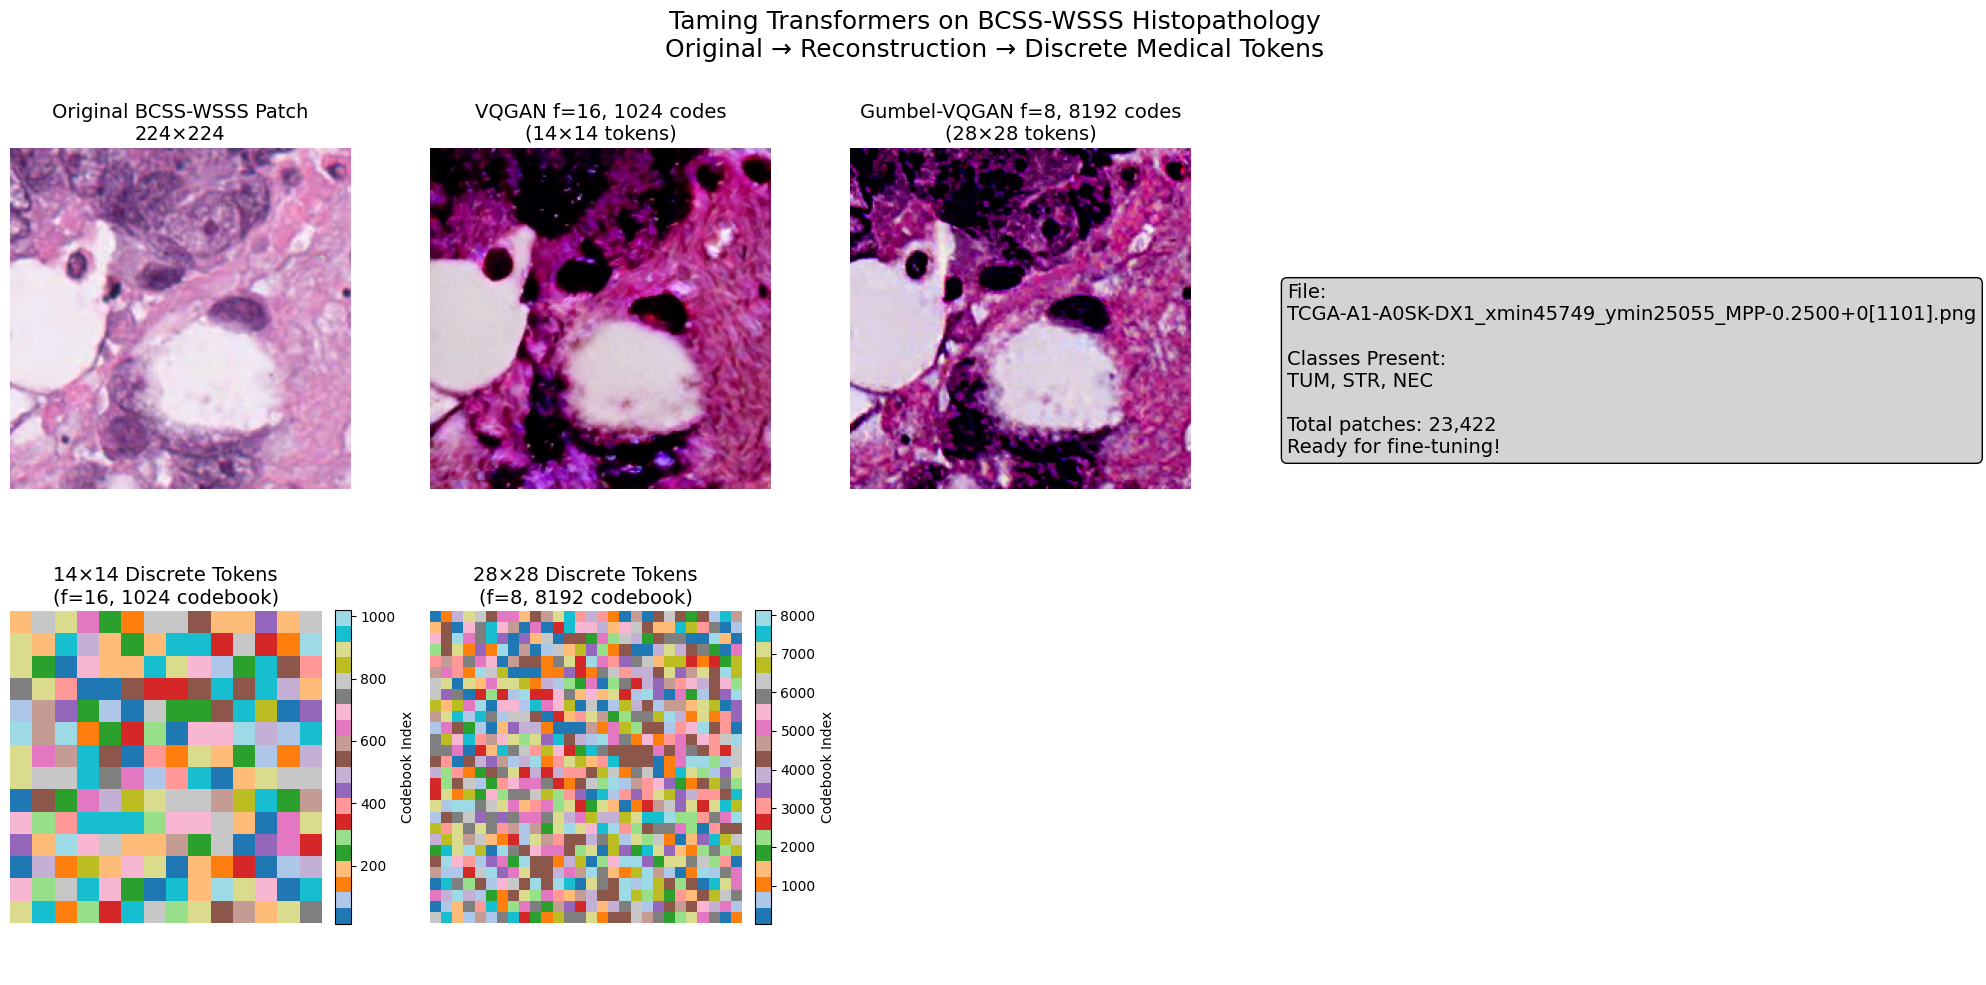

SUCCESS! YOU JUST TOKENIZED BREAST CANCER TISSUE!
These token maps are your future segmentation features!


In [21]:
# FINAL VISUALIZATION — Original + Reconstruction + TOKENS!
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Helper: convert [-1,1] tensor → displayable image
def tensor_to_pil(tensor):
    x = tensor.clone().detach().cpu()
    x = torch.clamp(x, -1, 1)
    x = (x + 1) / 2
    x = x.squeeze(0).permute(1, 2, 0).numpy()
    x = (255 * x).astype(np.uint8)
    return Image.fromarray(x)

# Convert all images
orig_img = tensor_to_pil(img_tensor)
recon1024_img = tensor_to_pil(recon1024)
recon_gumbel_img = tensor_to_pil(recon_gumbel)

# Extract token grids
tokens_1024 = indices1024.view(14, 14).cpu().numpy()        # f=16 → 224/ Crit16 = 14
tokens_gumbel = indices_gumbel.view(28, 28).cpu().numpy()   # f=8 → 224/8 = 28

print(f"Original patch: {path}")
print(f"Classes present: {classes}")
print(f"\nVQGAN f=16 (1024 codes) → 14×14 = {tokens_1024.size} tokens")
print(f"First 5×5 token grid (top-left):\n{tokens_1024[:5, :5]}")
print(f"Unique tokens used: {len(np.unique(tokens_1024))}")
print(f"\nGumbel f=8 (8192 codes) → 28×28 = {tokens_gumbel.size} tokens")
print(f"First 5×5 token grid (top-left):\n{tokens_gumbel[:5, :5]}")
print(f"Unique tokens used: {len(np.unique(tokens_gumbel))}")


fig = plt.figure(figsize=(20, 10))

# Original
plt.subplot(2, 4, 1)
plt.imshow(orig_img)
plt.title("Original BCSS-WSSS Patch\n224×224", fontsize=14)
plt.axis("off")

# Reconstructions
plt.subplot(2, 4, 2)
plt.imshow(recon1024_img)
plt.title("VQGAN f=16, 1024 codes\n(14×14 tokens)", fontsize=14)
plt.axis("off")

plt.subplot(2, 4, 3)
plt.imshow(recon_gumbel_img)
plt.title("Gumbel-VQGAN f=8, 8192 codes\n(28×28 tokens)", fontsize=14)
plt.axis("off")

# Token maps
plt.subplot(2, 4, 5)
im1 = plt.imshow(tokens_1024, cmap="tab20", interpolation="nearest")
plt.title("14×14 Discrete Tokens\n(f=16, 1024 codebook)", fontsize=14)
plt.colorbar(im1, fraction=0.046, pad=0.04, label="Codebook Index")
plt.axis("off")

plt.subplot(2, 4, 6)
im2 = plt.imshow(tokens_gumbel, cmap="tab20", interpolation="nearest")
plt.title("28×28 Discrete Tokens\n(f=8, 8192 codebook)", fontsize=14)
plt.colorbar(im2, fraction=0.046, pad=0.04, label="Codebook Index")
plt.axis("off")

# Info panel
plt.subplot(2, 4, (4, 8))
plt.text(0.05, 0.8, f"File:\n{path.split('/')[-1]}\n\nClasses Present:\n{', '.join(classes)}\n\nTotal patches: 23,422\nReady for fine-tuning!", 
         fontsize=14, verticalalignment='top', bbox=dict(boxstyle="round", facecolor="lightgray"))
plt.axis("off")

plt.suptitle("Taming Transformers on BCSS-WSSS Histopathology\n"
             "Original → Reconstruction → Discrete Medical Tokens", fontsize=18, y=0.98)
plt.tight_layout()
plt.show()

print("SUCCESS! YOU JUST TOKENIZED BREAST CANCER TISSUE!")
print("These token maps are your future segmentation features!")